Load data and libraries

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [2]:
df = pd.read_csv(
    "../data/processed/ratnapark/"
    "ratnapark_pm1_pm25_pm10_daily.csv"
)

df["date"] = pd.to_datetime(
    df["date"]
)

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Historical shape:", df.shape)

display(df.head())
display(df.tail())

Historical shape: (1887, 4)


,date,pm1,pm2_5,pm10
0,2016-08-25,144.026083,187.599837,269.346300
1,2016-08-27,121.881565,159.537520,230.975440
2,2016-08-28,98.196718,124.696523,171.362190
3,2016-08-29,54.083770,63.915300,78.042140
4,2016-09-07,127.947061,168.501950,245.585955


,date,pm1,pm2_5,pm10
1882,2025-12-27,62.634761,73.584236,92.353125
1883,2025-12-28,59.609465,70.560069,89.774583
1884,2025-12-29,60.442938,70.737011,88.259249
1885,2025-12-30,62.676937,75.665342,99.304639
1886,2025-12-31,59.515977,73.188123,98.925535


Create ewma features

In [3]:
df["pm2_5_ewma_3"] = (
    df["pm2_5"]
    .shift(1)
    .ewm(
        span=3,
        adjust=False
    )
    .mean()
)

df["pm2_5_ewma_7"] = (
    df["pm2_5"]
    .shift(1)
    .ewm(
        span=7,
        adjust=False
    )
    .mean()
)

df["pm10_ewma_3"] = (
    df["pm10"]
    .shift(1)
    .ewm(
        span=3,
        adjust=False
    )
    .mean()
)

df["pm10_ewma_7"] = (
    df["pm10"]
    .shift(1)
    .ewm(
        span=7,
        adjust=False
    )
    .mean()
)

In [4]:
pm25_features = [
    "pm2_5_ewma_3",
    "pm2_5_ewma_7",
    "pm10_ewma_3",
    "pm10_ewma_7",
]

print("Features:", len(pm25_features))

for feature in pm25_features:
    print("-", feature)

Features: 4
- pm2_5_ewma_3
- pm2_5_ewma_7
- pm10_ewma_3
- pm10_ewma_7


Prepare historical training data

In [5]:
train_df = df.dropna(
    subset=pm25_features + ["pm2_5"]
).copy()

print("Training rows:", len(train_df))

print(
    "Training date range:",
    train_df["date"].min(),
    "→",
    train_df["date"].max(),
)

Training rows: 1886
Training date range: 2016-08-27 00:00:00 → 2025-12-31 00:00:00


In [6]:
X_train = train_df[
    pm25_features
]

y_train = train_df[
    "pm2_5"
]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (1886, 4)
y_train: (1886,)


Train model

In [7]:
final_pm25_model = LinearRegression()

final_pm25_model.fit(
    X_train,
    y_train
)

print("PM2.5 model trained successfully.")

PM2.5 model trained successfully.


Inspect coefficients

In [8]:
print("Intercept:", final_pm25_model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    pm25_features,
    final_pm25_model.coef_
):
    print(
        f"{feature}: {coefficient:.6f}"
    )

Intercept: 5.93279778514048

Coefficients:
pm2_5_ewma_3: 0.678635
pm2_5_ewma_7: 0.334989
pm10_ewma_3: 0.470033
pm10_ewma_7: -0.532160


Load test data

In [9]:
test_pm25 = pd.read_csv("../data/processed/ratnapark/ratnapark_pm25_test_15days.csv")

test_pm25["date"] = pd.to_datetime(
    test_pm25["date"]
)

test_pm25 = (
    test_pm25
    .sort_values("date")
    .reset_index(drop=True)
)

print("Test shape:", test_pm25.shape)

display(test_pm25)

Test shape: (14, 7)


,date,pm2_5,pm10,pm2_5_ewma_3,pm2_5_ewma_7,pm10_ewma_3,pm10_ewma_7
0,2026-08-03 00:00:00+00:00,62.634817,75.393556,58.833538,58.833538,64.022251,64.022251
1,2026-08-04 00:00:00+00:00,58.748684,69.281502,60.734178,59.783858,69.707904,66.865077
2,2026-08-05 00:00:00+00:00,39.631938,49.294396,59.741431,59.525064,69.494703,67.469184
3,2026-08-06 00:00:00+00:00,41.120997,49.773565,49.686684,54.551783,59.394549,62.925487
4,2026-08-07 00:00:00+00:00,20.730946,31.665229,45.403841,51.194086,54.584057,59.637506
5,2026-08-08 00:00:00+00:00,13.310965,20.642748,33.067393,43.578301,43.124643,52.644437
6,2026-08-09 00:00:00+00:00,10.405691,17.865232,23.189179,36.011467,31.883696,44.644015
7,2026-08-10 00:00:00+00:00,9.005760,16.479667,16.797435,29.610023,24.874464,37.949319
8,2026-08-11 00:00:00+00:00,15.107986,26.751389,12.901597,24.458957,20.677066,32.581906
9,2026-08-12 00:00:00+00:00,14.218958,26.608750,14.004792,22.121214,23.714227,31.124277


Extract pm25 features

In [10]:
X_test = test_pm25[
    pm25_features
]

y_test = test_pm25[
    "pm2_5"
]

In [11]:
predictions = final_pm25_model.predict(
    X_test
)

add predictions to dataframe

In [13]:
test_pm25["predicted_pm2_5"] = predictions

Display

In [14]:
display(
    test_pm25[
        [
            "date",
            "pm2_5",
            "predicted_pm2_5"
        ]
    ]
)

,date,pm2_5,predicted_pm2_5
0,2026-08-03 00:00:00+00:00,62.634817,61.590400
1,2026-08-04 00:00:00+00:00,58.748684,64.358196
2,2026-08-05 00:00:00+00:00,39.631938,63.176098
3,2026-08-06 00:00:00+00:00,41.120997,52.357164
4,2026-08-07 00:00:00+00:00,20.730946,47.814525
5,2026-08-08 00:00:00+00:00,13.310965,35.226500
6,2026-08-09 00:00:00+00:00,10.405691,24.961876
7,2026-08-10 00:00:00+00:00,9.005760,18.747877
8,2026-08-11 00:00:00+00:00,15.107986,15.261881
9,2026-08-12 00:00:00+00:00,14.218958,17.430688


In [15]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("=" * 60)
print("PM2.5 FINAL UNSEEN TEST RESULTS")
print("=" * 60)

print(f"MAE :  {mae:.3f}")
print(f"RMSE:  {rmse:.3f}")
print(f"R²  :  {r2:.3f}")

PM2.5 FINAL UNSEEN TEST RESULTS
MAE :  9.969
RMSE:  13.016
R²  :  0.483


### So interestingly, MAE and RMSE are actually better than validation, while R² is substantially lower.

Plot

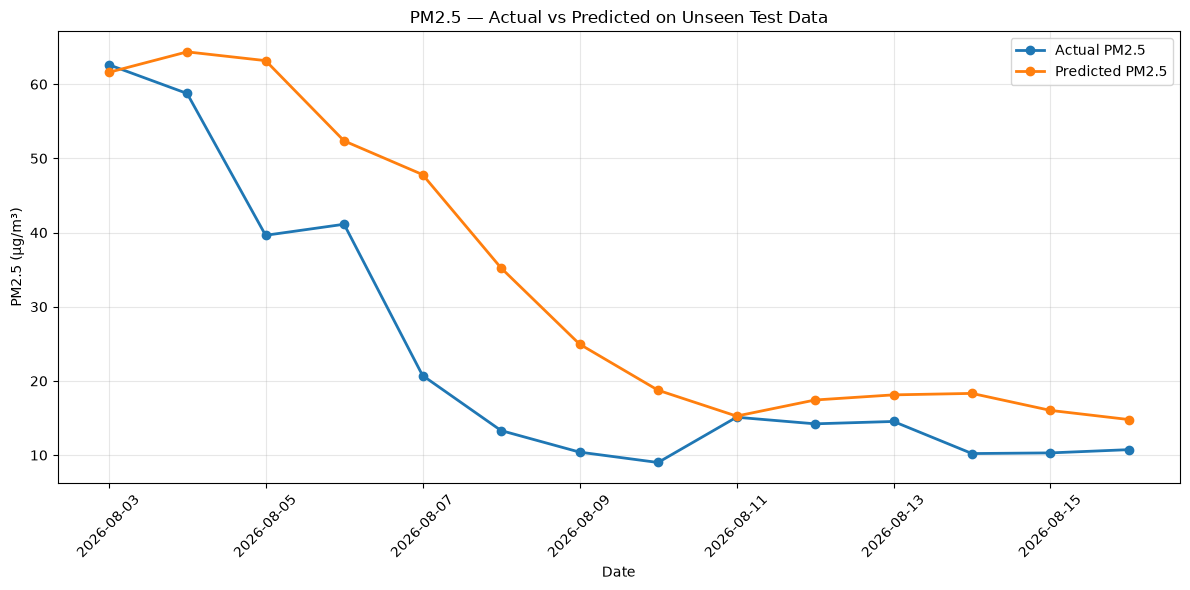

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test_pm25["date"],
    test_pm25["pm2_5"],
    marker="o",
    linewidth=2,
    label="Actual PM2.5"
)

plt.plot(
    test_pm25["date"],
    test_pm25["predicted_pm2_5"],
    marker="o",
    linewidth=2,
    label="Predicted PM2.5"
)

plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 — Actual vs Predicted on Unseen Test Data")

plt.xticks(rotation=45)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

## Now lets do forecasting for 8/17/2026

Prepare EWMA features


In [17]:
pm25_features = [
    "pm2_5_ewma_3",
    "pm2_5_ewma_7",
    "pm10_ewma_3",
    "pm10_ewma_7",
]

In [18]:
forecast_df = test_pm25.copy()

forecast_df["date"] = pd.to_datetime(
    forecast_df["date"]
)

forecast_df = (
    forecast_df
    .sort_values("date")
    .reset_index(drop=True)
)

In [19]:
forecast_df["pm2_5_ewma_3"] = (
    forecast_df["pm2_5"]
    .shift(1)
    .ewm(
        span=3,
        adjust=False
    )
    .mean()
)

forecast_df["pm2_5_ewma_7"] = (
    forecast_df["pm2_5"]
    .shift(1)
    .ewm(
        span=7,
        adjust=False
    )
    .mean()
)

forecast_df["pm10_ewma_3"] = (
    forecast_df["pm10"]
    .shift(1)
    .ewm(
        span=3,
        adjust=False
    )
    .mean()
)

forecast_df["pm10_ewma_7"] = (
    forecast_df["pm10"]
    .shift(1)
    .ewm(
        span=7,
        adjust=False
    )
    .mean()
)

In [20]:
latest = (
    forecast_df
    .sort_values("date")
    .iloc[-1]
)

print("Latest available date:", latest["date"])

print("\nFeatures for next-day forecast:")

for feature in pm25_features:
    print(
        f"{feature}: {latest[feature]:.4f}"
    )

Latest available date: 2026-08-16 00:00:00+00:00

Features for next-day forecast:
pm2_5_ewma_3: 11.2844
pm2_5_ewma_7: 15.1232
pm10_ewma_3: 17.8857
pm10_ewma_7: 23.2712


In [21]:
X_aug17 = pd.DataFrame(
    [[latest[feature] for feature in pm25_features]],
    columns=pm25_features
)

Predict aug 17

In [22]:
predicted_aug17 = final_pm25_model.predict(
    X_aug17
)[0]

print("=" * 60)
print("PM2.5 FORECAST")
print("=" * 60)

print("Forecast date: 2026-08-17")
print(
    f"Predicted PM2.5: {predicted_aug17:.2f} µg/m³"
)

PM2.5 FORECAST
Forecast date: 2026-08-17
Predicted PM2.5: 14.68 µg/m³


Save the model

In [23]:
import joblib
from pathlib import Path


MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = (
    MODEL_DIR /
    "pm25_linear_regression_ewma.joblib"
)

joblib.dump(
    final_pm25_model,
    model_path
)

print("Model saved:")
print(model_path)

Model saved:
..\models\pm25_linear_regression_ewma.joblib


Testing saved model

In [24]:
loaded_pm25_model = joblib.load(
    "../models/pm25_linear_regression_ewma.joblib"
)

print(loaded_pm25_model)

LinearRegression()


In [25]:
prediction = loaded_pm25_model.predict(
    X_aug17
)[0]

print(
    f"Predicted PM2.5: {prediction:.2f} µg/m³"
)

Predicted PM2.5: 14.68 µg/m³
